### RNN
##### RNN은 Sequential data를 위한 신경망이다.
##### Sequential data: 순서가 중요한 데이터, 즉 앞뒤의 배열이나 시간 흐름이 의미에 영향을 주는 데이터

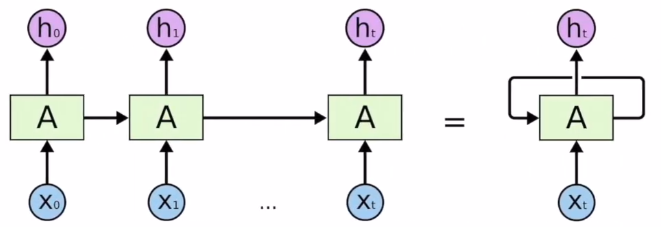


- 아무리 긴 문장이 들어와도 Cell A하나로 모두 처리가 가능하다.
- -> A라는 하나의 RNN Cell을 시간마다 계속 재사용한다.
- 옆으로 전달되는 값을 Hidden State라고 하는데 이전까지 읽는 내용을 요약한 벡터라고 생각하면 된다.(이전까지의 문맥을 압축해서 담고 있는 '기억 벡터')
- Cell = "한 번의 계산을 수행하는 작은 신경망"

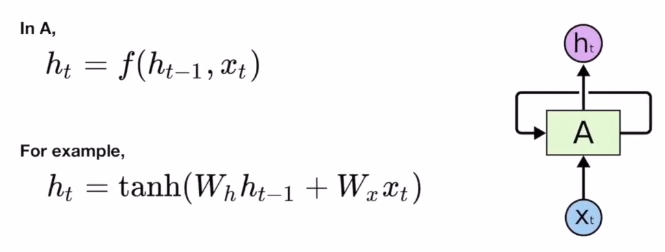


#### Cell A안에서는 왼쪽과 같은 연산이 이루어진다. 이전 state의 h값과 현재 state의 x값을 입력으로 받아 가중치를 곱하고 더한다. 여기서 나오는 가중치들은 학습의 대상들이다.

-----


### RNN in PyTorch


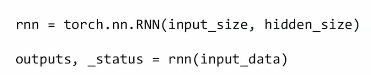

- 위의 코드 두 줄이면 RNN은 구현된다.
- input_data는 3차원 Tensor로 이루어지고 이 외에 나머지 코드들은 입력 데이터를 Tensor로 만들기 위한 코드일 뿐이다.


1. 첫 번째 차원: intput,output size



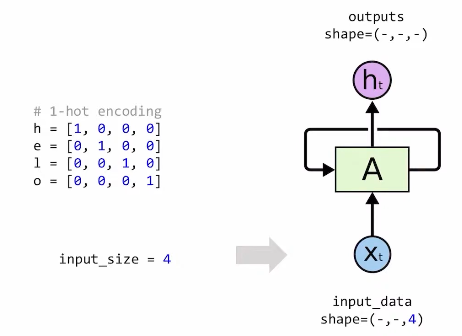

- input size는 각각의 문자 index를 보고 결정한다.(겹치는 문자는 뺀다.)

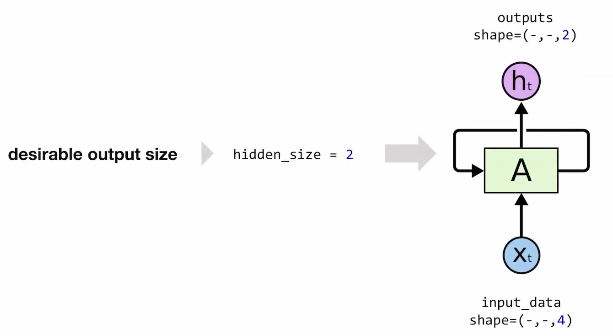

- hidden_size = 2이면 output_size = 2다. 왜냐하면 똑같은 h_t가 hidden state로도 가고 output으로 나가기 때문에 두 개의 size가 같다.


2. 두 번째 차원: Sequence Length

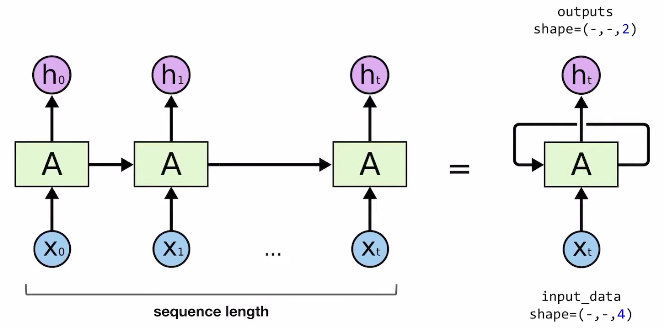

- 오른쪽 RNN 모델을 펼쳤을 때 sequence length가 t+1길이가 된다.

3. 세 번째 차원: Batch size

- Dataset에서 한 번에 몇 개를 동시에 학습시킬지를 정한다.
#### * 보통 input_size만 명시해주면 나머지는 모델이 알아서 자동으로 결정한다.

In [2]:
import torch
import numpy as np

input_size = 4
hidden_size = 2

# 1-hot encoding

h = [1, 0, 0, 0]
e = [0, 1, 0, 0]
l = [0, 0, 1, 0]
o = [0, 0, 0, 1]

input_data_np = np.array([[h, e, l, l, o],
                         [e, o, l, l, l],
                         [l, l, e, e, l]], dtype = np.float32)

input_data = torch.Tensor(input_data_np)
rnn = torch.nn.RNN(input_size, hidden_size)

outputs, _status = rnn(input_data) # outputs: 모든 hidden state가 저장되어 있고, _state: 마지막 hidden state만 저장되어 있음


------
### RNN HiHello, Charseq 코드 

In [1]:
import torch
import numpy as np
import torch.optim as optim

sample = "if you want you"
char_set = list(set(sample))
char_dic = {c: i for i, c in enumerate(char_set)}

dic_size = len(char_dic)
hidden = len(char_dic)
learning_rate =  0.1

sample_idx = [char_dic[c] for c in sample]
x_data = [sample_idx[:-1]]
x_one_hot = [np.eye(dic_size)[x] for x in x_data]
y_data = [sample_idx[1:]]

X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

rnn = torch.nn.RNN(dic_size, hidden, batch_first = True)
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(), learning_rate)

for i in range(100):
    optimizer.zero_grad()
    outputs, _status = rnn(X)
    loss = criterion(outputs.view(-1, dic_size), Y.view(-1))
    loss.backward()
    optimizer.step()
    result = outputs.data.numpy().argmax(axis = 2)
    result_str = ''.join([char_set[c] for c in np.squeeze(result)])
    print(i, "loss: ", loss.item(), "prediction: ", result, "true Y:", y_data, "prediction str:", result_str)
    



/tmp/ipykernel_6700/2373251275.py:18: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.FloatTensor(x_one_hot)


0 loss:  2.5305521488189697 prediction:  [[4 1 1 1 2 2 1 1 1 2 7 1 1 1]] true Y: [[1, 0, 6, 9, 8, 0, 4, 5, 3, 7, 0, 6, 9, 8]] prediction str: wfffiifffitfff
1 loss:  2.206116199493408 prediction:  [[4 6 6 1 1 6 4 1 1 2 6 6 1 1]] true Y: [[1, 0, 6, 9, 8, 0, 4, 5, 3, 7, 0, 6, 9, 8]] prediction str: wyyffywffiyyff
2 loss:  1.9262994527816772 prediction:  [[9 0 6 9 0 6 4 0 3 9 0 6 9 0]] true Y: [[1, 0, 6, 9, 8, 0, 4, 5, 3, 7, 0, 6, 9, 8]] prediction str: o yo yw no yo 
3 loss:  1.6920146942138672 prediction:  [[9 0 6 9 0 6 4 9 3 9 0 6 9 0]] true Y: [[1, 0, 6, 9, 8, 0, 4, 5, 3, 7, 0, 6, 9, 8]] prediction str: o yo ywono yo 
4 loss:  1.56280517578125 prediction:  [[9 0 6 9 0 6 4 9 3 9 0 6 9 8]] true Y: [[1, 0, 6, 9, 8, 0, 4, 5, 3, 7, 0, 6, 9, 8]] prediction str: o yo ywono you
5 loss:  1.4663809537887573 prediction:  [[9 0 6 9 8 6 4 9 3 9 0 6 9 8]] true Y: [[1, 0, 6, 9, 8, 0, 4, 5, 3, 7, 0, 6, 9, 8]] prediction str: o youywono you
6 loss:  1.3775140047073364 prediction:  [[9 0 6 9 8 0 4 5 3 

-----
### Longseq(긴 문장을 어떻게 처리할 것인가)


##### 긴 문장을 여러 문장으로 쪼개서 x,y로 나눠서 샘플을 만든다.
##### -> batch를 설정하든가 해서 학습한다.


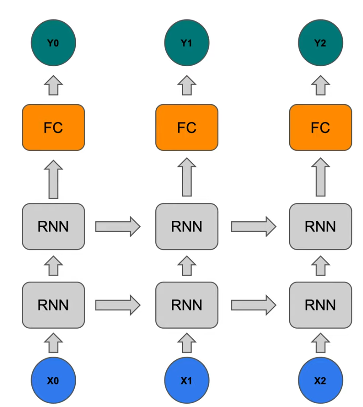

- 아래 코드의 model structure

In [8]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim


x_data = []
y_data = []
sentence = "if you want to build a ship, don't drun up people together to collect wood and don't assign them tasks and work, but rather teach them to long for the endlss immensity of the sea."
char_set = list(set(sentence))
char_dic = {c: i for i, c in enumerate(char_set)}

dic_size = len(char_dic)
hidden_size = len(char_dic)
learning_rate = 0.1
sequence_length = 5



for i in range(0, len(sentence) - sequence_length):
    x_str = sentence[i:i + sequence_length]
    y_str = sentence[i + 1: i + sequence_length + 1]
    print(i, x_str, '->', y_str)
    x_data.append([char_dic[c] for c in x_str])
    y_data.append([char_dic[c] for c in y_str])

x_one_hot = [np.eye(dic_size)[x] for x in x_data]

x = torch.FloatTensor(x_one_hot)
y = torch.LongTensor(y_data)

class Net(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, layers):
        super(Net, self).__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers = layers, batch_first = True)
        self.fc = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        x, _status = self.rnn(x)
        x = self.fc(x)
        return x


net = Net(dic_size, hidden_size, 2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)

for i in range(100):
    optimizer.zero_grad()
    outputs = net(x)
    loss = criterion(outputs.view(-1, dic_size), y.view(-1))
    loss.backward()
    optimizer.step()

    result = outputs.data.numpy().argmax(axis = 2)
    result_str = ''.join(char_set[c] for c in result.flatten())
    print(i, "loss: ", loss.item(), "prediction: ", result, "true Y:", y_data, "prediction str:", result_str)



0 if yo -> f you
1 f you ->  you 
2  you  -> you w
3 you w -> ou wa
4 ou wa -> u wan
5 u wan ->  want
6  want -> want 
7 want  -> ant t
8 ant t -> nt to
9 nt to -> t to 
10 t to  ->  to b
11  to b -> to bu
12 to bu -> o bui
13 o bui ->  buil
14  buil -> build
15 build -> uild 
16 uild  -> ild a
17 ild a -> ld a 
18 ld a  -> d a s
19 d a s ->  a sh
20  a sh -> a shi
21 a shi ->  ship
22  ship -> ship,
23 ship, -> hip, 
24 hip,  -> ip, d
25 ip, d -> p, do
26 p, do -> , don
27 , don ->  don'
28  don' -> don't
29 don't -> on't 
30 on't  -> n't d
31 n't d -> 't dr
32 't dr -> t dru
33 t dru ->  drun
34  drun -> drun 
35 drun  -> run u
36 run u -> un up
37 un up -> n up 
38 n up  ->  up p
39  up p -> up pe
40 up pe -> p peo
41 p peo ->  peop
42  peop -> peopl
43 peopl -> eople
44 eople -> ople 
45 ople  -> ple t
46 ple t -> le to
47 le to -> e tog
48 e tog ->  toge
49  toge -> toget
50 toget -> ogeth
51 ogeth -> gethe
52 gethe -> ether
53 ether -> ther 
54 ther  -> her t
55 her t -> er to
56

-----
### RNN-timeseries

###### Time Series Data: 일정한 시간 간격으로 배치된 데이터

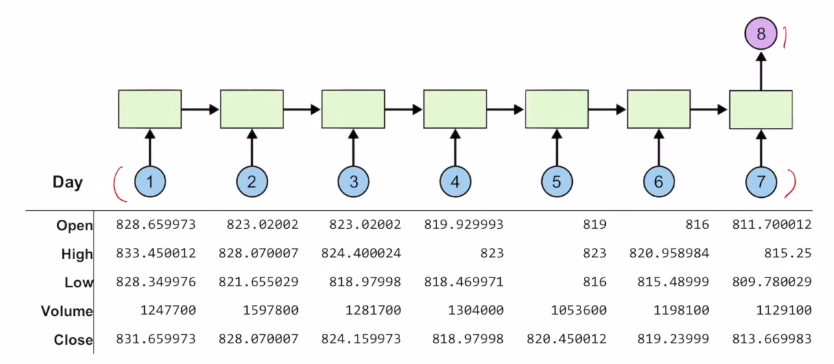

- 1주일 간의 데이터를 보고 8일차 종가를 예측하는 example
- 8일 째의 종가를 맞추기 위해서는 1-dimension이면 되지만 5가지의 정보를 1-dimension으로 압축하는 거는 너무 모델이 버겁기 때문에 10dimension으로 하고 마지막에 Fully Connected를 활용하여 1-dimension으로 바꿔서 8일 째의 종가를 예측한다.

[[0.         0.09562813 0.         0.52688515 0.        ]
 [0.20307547 0.         0.08720784 0.         0.09776238]
 [0.38026035 0.37196246 0.42571285 0.44352528 0.43827462]] -> [0.8997497]
[[0.20307547 0.         0.08720784 0.         0.09776238]
 [0.38026035 0.37196246 0.42571285 0.44352528 0.43827462]
 [0.7281562  0.834602   0.79457384 0.6630608  0.8997497 ]] -> [1.]
[[0.38026035 0.37196246 0.42571285 0.44352528 0.43827462]
 [0.7281562  0.834602   0.79457384 0.6630608  0.8997497 ]
 [0.97087497 1.         0.82752025 0.20330894 1.        ]] -> [0.87820786]
[[0.         0.         0.         0.26552737 0.02050551]
 [0.23696733 0.16339853 0.03965866 0.         0.11593317]
 [0.26540226 0.16339853 0.2472781  0.46012494 0.        ]] -> [0.408517]
[[0.23696733 0.16339853 0.03965866 0.         0.11593317]
 [0.26540226 0.16339853 0.2472781  0.46012494 0.        ]
 [0.31042662 0.27548093 0.1936231  0.41914737 0.408517  ]] -> [0.7168795]
[[0.26540226 0.16339853 0.2472781  0.46012494 0.        ]

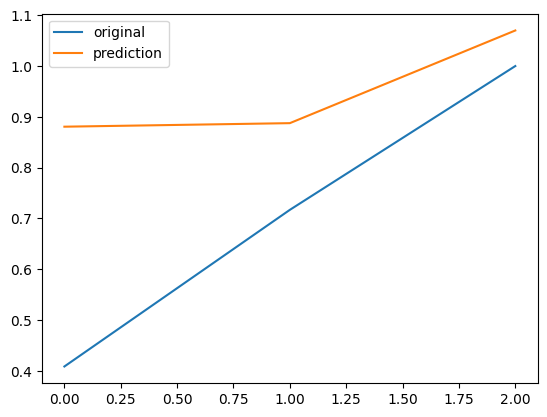

In [ ]:
# CSV가 다운이 안되어서 array로 대신 해서 결과가 좋지 않을 수 있지만 코드 위주로 확인

import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

class Net(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, layers):
        super(Net, self).__init__()
        self.rnn = torch.nn.LSTM(input_dim, hidden_dim, num_layers = layers, batch_first = True)
        self.fc = torch.nn.Linear(hidden_dim, output_dim, bias = True)

    def forward(self, x):
        x, _status = self.rnn(x)
        x = self.fc(x[:, -1])
        return x

def minmax_scaler(data):
    numerator = data - np.min(data, axis=0)

    denominator = (
        np.max(data, axis=0)
        - np.min(data, axis=0)
    )

    return numerator / (denominator + 1e-7)


def build_dataset(time_series, seq_length):
    dataX = []
    dataY = []

    for i in range(
        len(time_series) - seq_length
    ):
        x = time_series[
            i:i + seq_length,
            :
        ]

        y = time_series[
            i + seq_length,
            [-1]
        ]

        print(x, "->", y)

        dataX.append(x)
        dataY.append(y)

    return (
        np.array(dataX),
        np.array(dataY)
    )

seq_length = 3
data_dim = 5
hidden_dim = 10
output_dim = 1
learning_rate = 0.01
iterations = 500


xy = np.array([
    [828.659973, 833.450012, 828.349976, 1247700, 831.659973],
    [823.020020, 828.070007, 821.655029, 1597800, 828.070007],
    [819.929993, 824.400024, 817.979980, 1281700, 824.159973],
    [819.359985, 823.000000, 818.669971, 1304000, 818.979980],
    [819.000000, 823.000000, 816.000000, 1053600, 820.450012],
    [816.000000, 820.958984, 815.489990, 1198100, 819.239990],
    [811.700012, 815.250000, 809.780029, 1129100, 813.669983],
    [809.510010, 810.659973, 804.539978, 989700, 809.559998],
    [807.000000, 811.840027, 803.190002, 1155300, 808.380005]
], dtype=np.float32)
xy = xy[::-1]

train_size = int(len(xy) * 0.7)
train_set = xy[0:train_size]
test_set = xy[train_size - seq_length:] # 이렇게 하는 이유는 RNN은 값을 예측하려면 이전 seq_length만큼 값이 필요하기 때문이다.

train_set = minmax_scaler(train_set)
test_set = minmax_scaler(test_set)

trainX, trainY = build_dataset(train_set, seq_length)
testX, testY = build_dataset(test_set, seq_length)

trainX_tensor = torch.FloatTensor(trainX)
trainY_tensor = torch.FloatTensor(trainY)

testX_tensor = torch.FloatTensor(testX)
testY_tensor = torch.FloatTensor(testY)

net = Net(data_dim, hidden_dim, output_dim, 1)
criterion = torch.nn.MSELoss()
optimizer = optim.Adam(net.parameters(), lr = learning_rate)

for i in range(iterations):

    optimizer.zero_grad()
    outputs = net(trainX_tensor)
    loss = criterion(outputs, trainY_tensor)
    loss.backward()
    optimizer.step()
    print(i, loss.item())

plt.plot(testY)
plt.plot(net(testX_tensor).data.numpy())
plt.legend(['original', 'prediction'])
plt.show()


----
### RNN - Seq2Seq

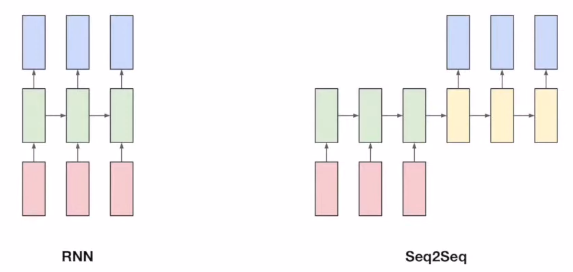

- Seq2Seq는 입력 시퀀스를 출력 시퀀스로 변환하는 모델로, 주로 기계 번역에 사용된다. 기본적인 Seq2Seq 모델은 두 개의 RNN으로 구성되며, 입력 문장을 처리하는 Encoder와 출력 문장을 생성하는 Decoder로 이루어진다.

In [ ]:
import random
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

raw = ["I feel hungry. 나는 배가 고프다",
       "Pytorch is very easy. 파이토치는 매우 쉽다",
       "I love you. 나는 너를 사랑해",
       "I am hungry. 나는 배가 고프다"]

SOS_token = 0
EOS_token = 1

def preprocess(corpus, source_max_length, target_max_length):
    print("reading corpus...")

    pairs = []

    for line in corpus:
        pairs.append(
            [
                s
                for s in line.strip().lower().split("\t")
            ]
        )

    print("Read {} sentence pairs".format(len(pairs)))

    pairs = [
        pair
        for pair in pairs
        if filter_pair(
            pair,
            source_max_length,
            target_max_length
        )
    ]

    print("Trimmed to {} sentence pairs".format(len(pairs)))

    source_vocab = Vocab()
    target_vocab = Vocab()

    print("Counting words...")

    for pair in pairs:
        source_vocab.add_vocab(pair[0])
        target_vocab.add_vocab(pair[1])

    print("source vocab size =", source_vocab.n_vocab)
    print("target vocab size =", target_vocab.n_vocab)

    return pairs, source_vocab, target_vocab

class Encoder(nn.Module):
    

    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(
            input_size,
            hidden_size
        )
        self.gru = nn.GRU(
            hidden_size,
            hidden_size
        )

    def forward(self, x, hidden):
       

        x = self.embedding(x).view(1, 1, -1)
        x, hidden = self.gru(x, hidden)
        return x, hidden


class Decoder(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(Decoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(
            output_size,
            hidden_size
        )
        self.gru = nn.GRU(
            hidden_size,
            hidden_size
        )
        self.out = nn.Linear(
            hidden_size,
            output_size
        )
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x, hidden):
        x = self.embedding(x).view(1, 1, -1)
        x, hidden = self.gru(
            x,
            hidden
        )
        x = self.softmax(self.out(x[0]))

        return x, hidden


def tensorize(vocab, sentence):
    indexes = [vocab.vocab2index[word] for word in sentence.split(" ")]
    indexes.append(vocab.vocab2index["<EOS>"])
    return torch.Tensor(indexes).long().to(device).view(-1, 1)


def train(
    pairs,
    source_vocab,
    target_vocab,
    encoder,
    decoder,
    n_iter,
    print_every=1000,
    learning_rate=0.01
):
    loss_total = 0

    encoder_optimizer = optim.SGD(
        encoder.parameters(),
        lr=learning_rate
    )

    decoder_optimizer = optim.SGD(
        decoder.parameters(),
        lr=learning_rate
    )

    training_batch = [
        random.choice(pairs)
        for _ in range(n_iter)
    ]

    training_source = [
        tensorize(source_vocab, pair[0])
        for pair in training_batch
    ]

    training_target = [
        tensorize(target_vocab, pair[1])
        for pair in training_batch
    ]

    criterion = nn.NLLLoss()

    # encoder hidden state 처음에는 0으로 초기화 한 값들이 들어가고 Decoder hidden state 처음에는 
    # Encoder hidden state 마지막에 나온 값이 들어가게 된다.
    for i in range(1, n_iter + 1):
        source_tensor = training_source[i - 1]
        target_tensor = training_target[i - 1]

        encoder_hidden = torch.zeros(
            [1, 1, encoder.hidden_size]
        ).to(device)

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        source_length = source_tensor.size(0)
        target_length = target_tensor.size(0)

        loss = 0

        for enc_input in range(source_length):
            _, encoder_hidden = encoder(
                source_tensor[enc_input],
                encoder_hidden
            )
    decoder_input = torch.Tensor([[SOS_token]]).long().to(device)
    decoder_hidden = encoder_hidden

    for di in range(target_length):
        decoder_output, decoder_hidden = decoder(
            decoder_input,
            decoder_hidden
        )

        loss += criterion(
            decoder_output,
            target_tensor[di]
        )

        # Teacher Forcing:
        # 실제 정답 단어를 다음 Decoder 입력으로 사용
        decoder_input = target_tensor[di]

    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    loss_iter = loss.item() / target_length
    loss_total += loss_iter

    if i % print_every == 0:
        loss_avg = loss_total / print_every
        loss_total = 0

        print(
            "[{} - {:.0f}%] loss = {:.4f}".format(
                i,
                i / n_iter * 100,
                loss_avg
            )
        )

---
### RNN - PackedSequence
###### size가 다른 Sequnce 데이터들을 어떻게 처리할까?

1. Padding Method

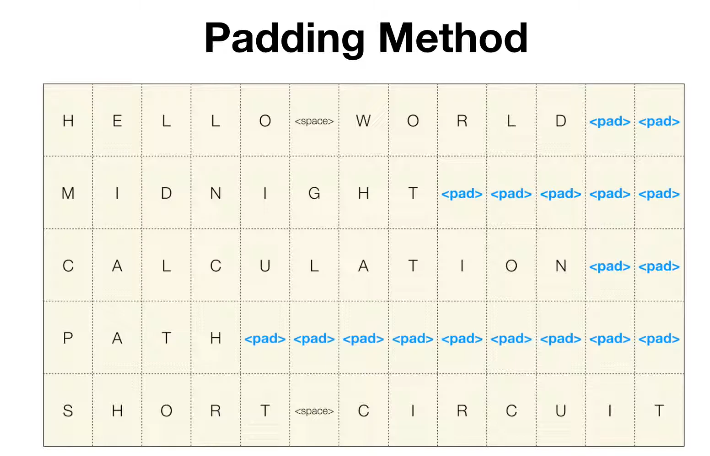

- 가장 긴 Sequence에 맞춰서 패딩을 진행한다.

2. Packing Method

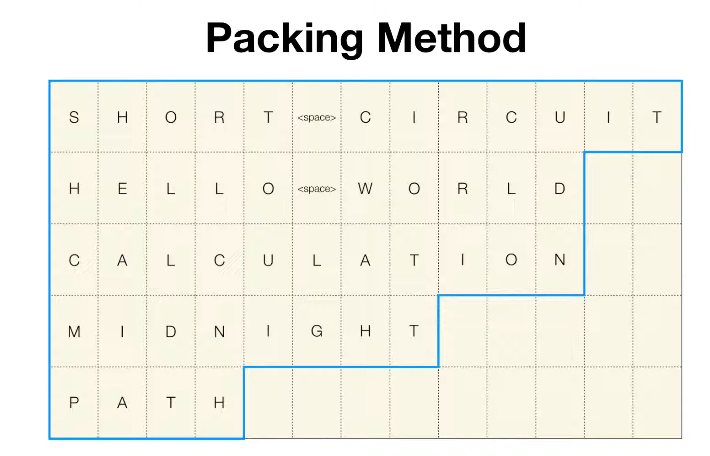

- Packing Method는 길이 내림차순으로 정렬시켜야지 작동한다.


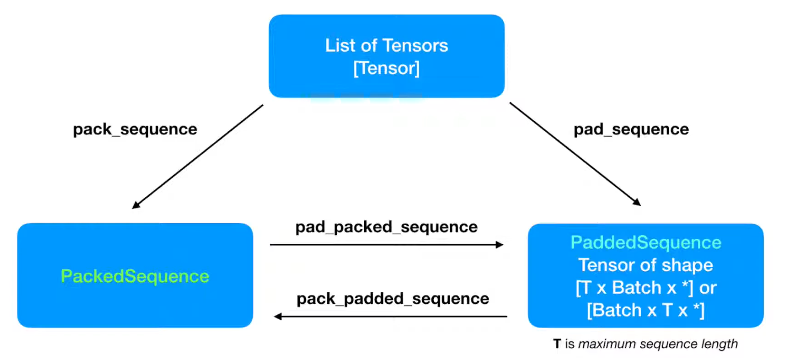

- 위의 함수들을 이용해서 Padding이나 Packing으로 바꿀 수 있다.

### LSTM
##### LSTM이 나온 이유: RNN을 사용하면 문장이 길어지게 될 경우 SGD에 의해서 가중치를 업데이트 할 때 W의 기울기가 1보다 작을 경우 gradient vanishing이 일어나고 1보다 클 경우에는 gradient exploding이 일어나기 때문이다.